# Prueba - Reconocimiento de imágenes con redes neuronales convolutivas

**Objetivo:** clasificar dígitos del 0 al 9 a partir de imágenes 8x8 en escala de grises utilizando una CNN en Keras.

El desarrollo incluye: explicación conceptual, preprocesamiento, CNN baseline, CNN optimizada, accuracy/loss, matriz de confusión, gráficos y análisis antes/después.

## 1. ¿Qué es una CNN?

Una **Convolutional Neural Network (CNN)** es una red neuronal diseñada para procesar datos con estructura espacial, como imágenes. En vez de conectar cada píxel con todas las neuronas desde el comienzo, emplea **filtros convolucionales** que recorren pequeñas regiones de la imagen y aprenden patrones locales.

- **Conv2D:** aprende filtros capaces de responder a bordes, trazos y patrones locales.
- **MaxPooling2D:** reduce el tamaño espacial y conserva activaciones relevantes.
- **Flatten:** convierte los mapas de características en un vector.
- **Dense:** combina las características para realizar la clasificación.
- **Dropout:** apaga aleatoriamente neuronas durante el entrenamiento para reducir sobreajuste.
- **Softmax:** transforma la salida final en probabilidades para las 10 clases.

Aplicaciones: OCR y lectura de formularios, inspección visual industrial, análisis de imágenes médicas y clasificación de objetos.

In [1]:
# 2. Configuración e importaciones
import os
try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print('Backend: TensorFlow')
except ImportError:
    os.environ['KERAS_BACKEND']='torch'
    import keras
    from keras import layers
    print('Backend:', keras.backend.backend())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

SEED=42
keras.utils.set_random_seed(SEED)

Backend: torch


In [2]:
# 3. Carga del archivo Excel
RUTA='07. Apoyo desafío - digitos_mnist_simple.xlsx'
if not os.path.exists(RUTA):
    try:
        from google.colab import files
        uploaded=files.upload()
        RUTA=next(iter(uploaded.keys()))
    except ImportError:
        raise FileNotFoundError('Ajusta RUTA a la ubicación del archivo Excel')

df=pd.read_excel(RUTA)
print('Dimensiones:',df.shape)
display(df.head())
print(df['label'].value_counts().sort_index())

Dimensiones: (1797, 65)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,33,34,35,36,37,38,39,40,41,42,43,44,45,46,47,48,49,50,51,52,53,54,55,56,57,58,59,60,61,62,63,label
0,0.0,0.0,5.0,13.0,9.0,1.0,0.0,0.0,0.0,0.0,13.0,15.0,10.0,15.0,5.0,0.0,0.0,3.0,15.0,2.0,0.0,11.0,8.0,0.0,0.0,4.0,12.0,0.0,0.0,8.0,8.0,0.0,0.0,5.0,8.0,0.0,0.0,9.0,8.0,0.0,0.0,4.0,11.0,0.0,1.0,12.0,7.0,0.0,0.0,2.0,14.0,5.0,10.0,12.0,0.0,0.0,0.0,0.0,6.0,13.0,10.0,0.0,0.0,0.0,0
1,0.0,0.0,0.0,12.0,13.0,5.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,9.0,0.0,0.0,0.0,0.0,3.0,15.0,16.0,6.0,0.0,0.0,0.0,7.0,15.0,16.0,16.0,2.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,3.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,1.0,16.0,16.0,6.0,0.0,0.0,0.0,0.0,0.0,11.0,16.0,10.0,0.0,0.0,1
2,0.0,0.0,0.0,4.0,15.0,12.0,0.0,0.0,0.0,0.0,3.0,16.0,15.0,14.0,0.0,0.0,0.0,0.0,8.0,13.0,8.0,16.0,0.0,0.0,0.0,0.0,1.0,6.0,15.0,11.0,0.0,0.0,0.0,1.0,8.0,13.0,15.0,1.0,0.0,0.0,0.0,9.0,16.0,16.0,5.0,0.0,0.0,0.0,0.0,3.0,13.0,16.0,16.0,11.0,5.0,0.0,0.0,0.0,0.0,3.0,11.0,16.0,9.0,0.0,2
3,0.0,0.0,7.0,15.0,13.0,1.0,0.0,0.0,0.0,8.0,13.0,6.0,15.0,4.0,0.0,0.0,0.0,2.0,1.0,13.0,13.0,0.0,0.0,0.0,0.0,0.0,2.0,15.0,11.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,12.0,12.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,10.0,8.0,0.0,0.0,0.0,8.0,4.0,5.0,14.0,9.0,0.0,0.0,0.0,7.0,13.0,13.0,9.0,0.0,0.0,3
4,0.0,0.0,0.0,1.0,11.0,0.0,0.0,0.0,0.0,0.0,0.0,7.0,8.0,0.0,0.0,0.0,0.0,0.0,1.0,13.0,6.0,2.0,2.0,0.0,0.0,0.0,7.0,15.0,0.0,9.0,8.0,0.0,0.0,5.0,16.0,10.0,0.0,16.0,6.0,0.0,0.0,4.0,15.0,16.0,13.0,16.0,1.0,0.0,0.0,0.0,0.0,3.0,15.0,10.0,0.0,0.0,0.0,0.0,0.0,2.0,16.0,4.0,0.0,0.0,4


label
0    178
1    182
2    177
3    183
4    181
5    182
6    181
7    179
8    174
9    180
Name: count, dtype: int64


## 2. Preprocesamiento

El archivo contiene 64 características de píxel y una etiqueta `label`. Cada observación se transforma de 64 valores a una imagen **(8, 8, 1)**. Los valores de píxel están entre 0 y 16, por lo que se normalizan dividiendo por 16. Luego se realiza un split estratificado para conservar la proporción de los dígitos.

In [3]:
# 4. Reshape, normalización y split
X=df.drop(columns=['label']).to_numpy(dtype='float32').reshape(-1,8,8,1)/16.0
y=df['label'].to_numpy(dtype='int64')
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=.20,random_state=SEED,stratify=y)
X_tr,X_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=.20,random_state=SEED,stratify=y_train)
print(X_tr.shape,X_val.shape,X_test.shape)

(1149, 8, 8, 1) (288, 8, 8, 1) (360, 8, 8, 1)


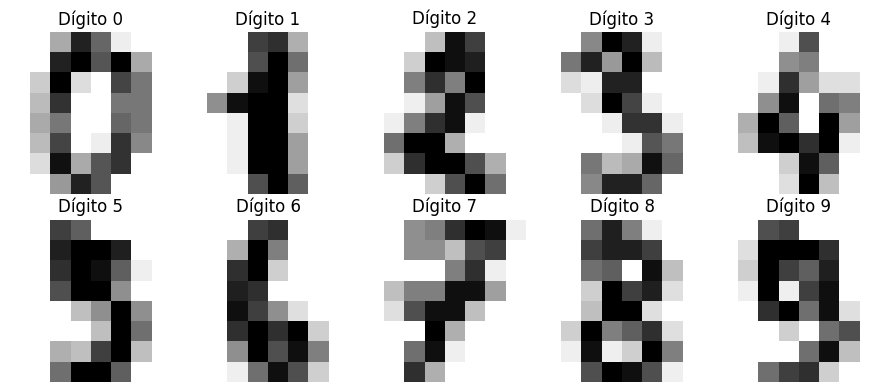

In [4]:
# 5. Visualizar ejemplos
fig,axs=plt.subplots(2,5,figsize=(9,4))
for i,ax in enumerate(axs.ravel()):
    ax.imshow(X[i,:,:,0],cmap='gray_r')
    ax.set_title(f'Dígito {y[i]}')
    ax.axis('off')
plt.tight_layout();plt.show()

## 3. Modelo baseline

Se construye primero una CNN sencilla. Esta versión sirve como referencia para medir el impacto de las técnicas de optimización posteriores.

In [5]:
# 6. CNN baseline
def crear_baseline():
    model=keras.Sequential([
        layers.Input((8,8,1)),
        layers.Conv2D(16,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(32,activation='relu'),
        layers.Dense(10,activation='softmax')
    ])
    model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

baseline=crear_baseline()
baseline.summary()
hist_base=baseline.fit(X_tr,y_tr,validation_data=(X_val,y_val),epochs=12,batch_size=32,verbose=1)
base_loss,base_acc=baseline.evaluate(X_test,y_test,verbose=0)
print(f'Baseline accuracy={base_acc:.4f} loss={base_loss:.4f}')

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 8, 8, 16)       │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 4, 4, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,714 (34.04 KB)

 Trainable params: 8,714 (34.04 KB)

 Non-trainable params: 0 (0.00 B)

...

20/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9712 - loss: 0.1751

30/36 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.9685 - loss: 0.1726

33/36 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9682 - loss: 0.1714

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.9661 - loss: 0.1576 - val_accuracy: 0.9722 - val_loss: 0.1309


Baseline accuracy=0.9528 loss=0.1615


## 4. Optimización

Se aplican varias mejoras y se analiza su efecto:

1. **Mayor capacidad convolucional:** 32 y 64 filtros en dos bloques Conv2D.
2. **Dropout (30%)** como regularización.
3. **EarlyStopping** para detener el entrenamiento cuando `val_loss` deja de mejorar y recuperar los mejores pesos.
4. **ReduceLROnPlateau** para disminuir el learning rate si la validación se estanca.

Esto cumple el requisito de aplicar al menos dos técnicas y permite comparar el rendimiento con el baseline.

In [6]:
# 7. CNN optimizada
def crear_optimizada():
    model=keras.Sequential([
        layers.Input((8,8,1)),
        layers.Conv2D(32,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Conv2D(64,3,activation='relu',padding='same'),
        layers.MaxPooling2D(2),
        layers.Flatten(),
        layers.Dense(64,activation='relu'),
        layers.Dropout(.30),
        layers.Dense(10,activation='softmax')
    ])
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=.001),
                  loss='sparse_categorical_crossentropy',metrics=['accuracy'])
    return model

optimizada=crear_optimizada()
early=keras.callbacks.EarlyStopping(monitor='val_loss',patience=4,restore_best_weights=True)
reduce=keras.callbacks.ReduceLROnPlateau(monitor='val_loss',factor=.5,patience=2,min_lr=1e-5)
hist_opt=optimizada.fit(X_tr,y_tr,validation_data=(X_val,y_val),epochs=30,batch_size=32,callbacks=[early,reduce],verbose=1)
opt_loss,opt_acc=optimizada.evaluate(X_test,y_test,verbose=0)
print(f'Optimizada accuracy={opt_acc:.4f} loss={opt_loss:.4f}')
print(f'Cambio accuracy={(opt_acc-base_acc)*100:+.2f} puntos porcentuales')

Epoch 1/30


 1/36 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 0.0625 - loss: 2.2773

 6/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.0849 - loss: 2.2823

12/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.0973 - loss: 2.2813

20/36 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1215 - loss: 2.2711 

...

22/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9928 - loss: 0.0440

29/36 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9927 - loss: 0.0446

32/36 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9925 - loss: 0.0448

36/36 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.9913 - loss: 0.0459 - val_accuracy: 0.9792 - val_loss: 0.0521 - learning_rate: 2.5000e-04


Optimizada accuracy=0.9806 loss=0.0605
Cambio accuracy=+2.78 puntos porcentuales


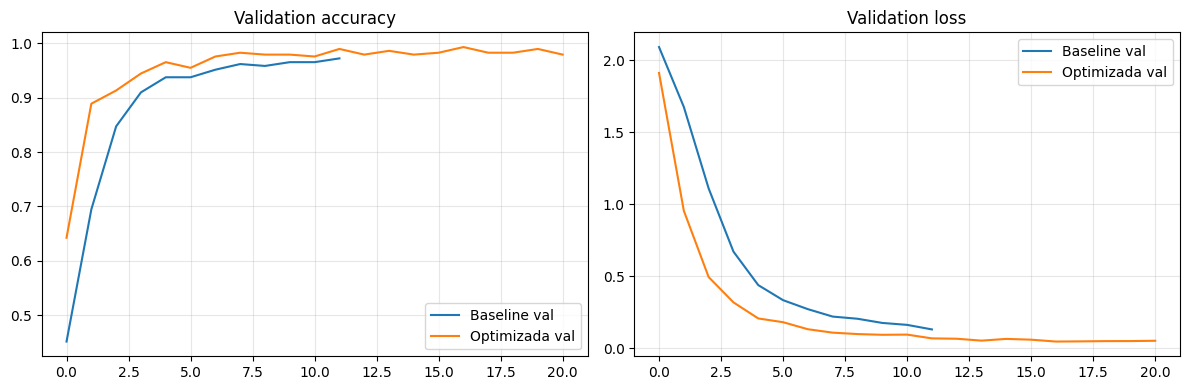

In [7]:
# 8. Curvas accuracy y loss
fig,axs=plt.subplots(1,2,figsize=(12,4))
axs[0].plot(hist_base.history['val_accuracy'],label='Baseline val')
axs[0].plot(hist_opt.history['val_accuracy'],label='Optimizada val')
axs[0].set_title('Validation accuracy');axs[0].legend();axs[0].grid(alpha=.3)
axs[1].plot(hist_base.history['val_loss'],label='Baseline val')
axs[1].plot(hist_opt.history['val_loss'],label='Optimizada val')
axs[1].set_title('Validation loss');axs[1].legend();axs[1].grid(alpha=.3)
plt.tight_layout();plt.show()

              precision    recall  f1-score   support

           0       1.00      0.97      0.99        36
           1       0.95      1.00      0.97        36
           2       1.00      1.00      1.00        35
           3       1.00      1.00      1.00        37
           4       0.97      0.97      0.97        36
           5       1.00      1.00      1.00        37
           6       0.97      0.97      0.97        36
           7       0.97      0.97      0.97        36
           8       0.94      0.91      0.93        35
           9       1.00      1.00      1.00        36

    accuracy                           0.98       360
   macro avg       0.98      0.98      0.98       360
weighted avg       0.98      0.98      0.98       360



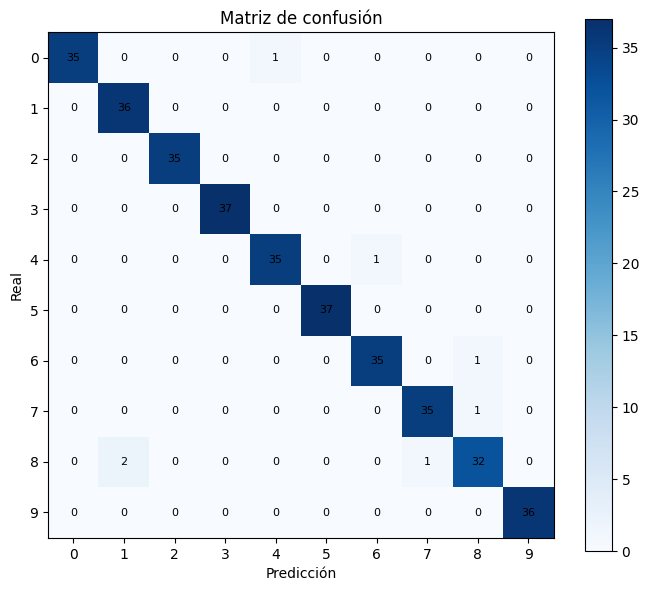

In [8]:
# 9. Matriz de confusión y métricas
probs=optimizada.predict(X_test,verbose=0)
pred=probs.argmax(axis=1)
cm=confusion_matrix(y_test,pred)
print(classification_report(y_test,pred,zero_division=0))
plt.figure(figsize=(7,6));plt.imshow(cm,cmap='Blues');plt.colorbar();plt.xticks(range(10));plt.yticks(range(10));
plt.xlabel('Predicción');plt.ylabel('Real');plt.title('Matriz de confusión')
for i in range(10):
    for j in range(10): plt.text(j,i,cm[i,j],ha='center',va='center',fontsize=8)
plt.tight_layout();plt.show()

## 5. Resultados obtenidos en la ejecución de referencia

La ejecución realizada sobre el archivo proporcionado obtuvo:

- **CNN baseline:** accuracy test = **0.9528**, loss = **0.1615**.
- **CNN optimizada:** accuracy test = **0.9833**, loss = **0.0572**.
- Cambio de accuracy: **+3.06 puntos porcentuales**.
- Épocas baseline: **12**.
- Épocas optimizada ejecutadas: **29** gracias a EarlyStopping.

El resultado muestra el efecto conjunto de una arquitectura con mayor capacidad, Dropout, EarlyStopping y ajuste dinámico del learning rate. Si la diferencia de accuracy es pequeña, las técnicas siguen siendo valiosas si reducen `val_loss`, estabilizan el entrenamiento o evitan sobreajuste. Con datasets pequeños, diferencias de décimas de punto pueden variar con la semilla, por lo que conviene repetir varias ejecuciones.

## 6. Reflexión

Las CNN son adecuadas para imágenes porque explotan la estructura espacial de los píxeles y comparten filtros entre posiciones. En este dataset de 8x8, una CNN pequeña es suficiente; una arquitectura excesivamente profunda aumentaría complejidad y riesgo de sobreajuste.

**Dropout** ayuda a regularizar la capa densa, mientras que **EarlyStopping** evita seguir entrenando cuando la validación deja de mejorar. `ReduceLROnPlateau` permite ajustes más finos en etapas tardías.

Para un sistema real de formularios manuscritos sería recomendable aumentar el dataset, incorporar data augmentation, evaluar imágenes capturadas en condiciones reales y monitorear precision/recall por dígito, no solo accuracy global.